#Market & Stock Rationale

In [ ]:
!pip install pykalman yfinance seaborn scikit-learn PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.4/249.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.5/149.5 kB 4.8 MB/s eta 0:00:00


#Setup and Installation

#Import Libraries and Load Data

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns


In [ ]:
# Define tickers (UK retail sector + FTSE index)
tickers = ['SBRY.L', 'TSCO.L', 'MKS.L', 'KGF.L', 'NXT.L', 'OCDO.L', '^FTSE']

# Download data from Yahoo Finance
data = yf.download(tickers, start='2024-11-01', end='2025-11-01', auto_adjust=False)


[*********************100%***********************]  7 of 7 completed


In [ ]:
data = data['Close']

#Clustering Analysis (KMeans)

In [ ]:
returns = data.pct_change().dropna()

In [ ]:
# Define portfolio assets
assets = ['SBRY.L', 'TSCO.L', 'MKS.L', 'KGF.L', 'NXT.L', 'OCDO.L']

# Subset returns for portfolio assets
portfolio_returns = returns[assets]

# Annualized expected return
mean_returns = portfolio_returns.mean() * 252

# Annualized volatility
volatility = portfolio_returns.std() * np.sqrt(252)

# Correlation matrix
corr_matrix = portfolio_returns.corr()

# Create features DataFrame
features = pd.DataFrame({
    "MeanReturn": mean_returns,
    "Volatility": volatility
})

# Display features
display(features)


,MeanReturn,Volatility
Ticker,,
SBRY.L,0.280386,0.225758
TSCO.L,0.303200,0.224299
MKS.L,0.085162,0.287728
KGF.L,0.096344,0.332617
NXT.L,0.395989,0.245082
OCDO.L,-0.291017,0.593972


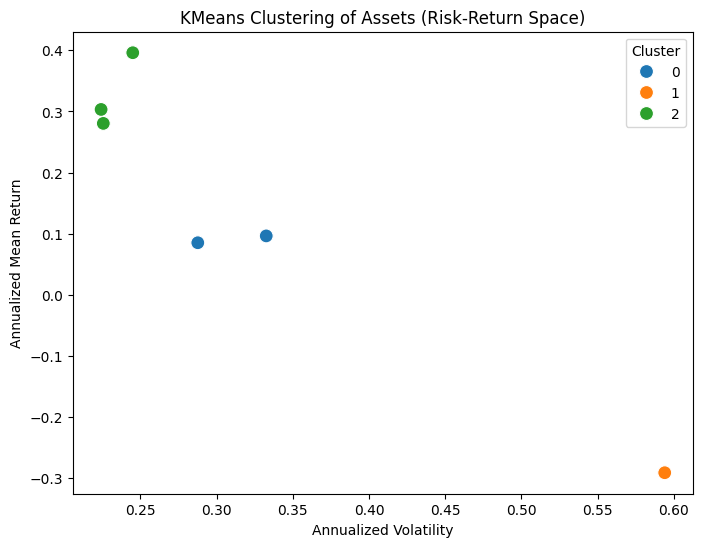

,MeanReturn,Volatility,Cluster
Ticker,,,
KGF.L,0.096344,0.332617,0
MKS.L,0.085162,0.287728,0
OCDO.L,-0.291017,0.593972,1
TSCO.L,0.303200,0.224299,2
SBRY.L,0.280386,0.225758,2
NXT.L,0.395989,0.245082,2


In [ ]:
# Scale features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
features["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualize clustering
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x="Volatility", y="MeanReturn", hue="Cluster", palette="tab10", s=100)
plt.title("KMeans Clustering of Assets (Risk-Return Space)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Mean Return")
plt.show()

# Display sorted features with cluster labels
display(features.sort_values("Cluster"))

#Return Calculation

returns = data.pct_change().dropna()

In [ ]:
rf_annual = 0.04
rf_daily = rf_annual / 252

In [ ]:
returns.head()

Ticker,KGF.L,MKS.L,NXT.L,OCDO.L,SBRY.L,TSCO.L,^FTSE
Date,,,,,,,
2024-11-04,0.009440,0.003677,-0.003228,0.022286,0.003776,0.010920,0.000856
2024-11-05,-0.005678,0.003401,0.015989,-0.016769,0.000752,0.005969,-0.001442
2024-11-06,-0.017131,0.038331,-0.013745,-0.003411,0.006767,0.009607,-0.000697
2024-11-07,-0.009228,-0.012557,0.002020,-0.008557,-0.041075,-0.024629,-0.003184
2024-11-08,-0.000345,-0.047559,-0.006047,-0.017837,-0.029595,-0.009469,-0.008390


#Expected Return

In [ ]:
expected_return = returns[['SBRY.L', 'TSCO.L', 'MKS.L','KGF.L','NXT.L','OCDO.L']].mean() * 252

In [ ]:
expected_return

,0
Ticker,
SBRY.L,0.280386
TSCO.L,0.303200
MKS.L,0.085162
KGF.L,0.096344
NXT.L,0.395989
OCDO.L,-0.291017


#Volatility

In [ ]:
volatility = returns[['SBRY.L', 'TSCO.L', 'MKS.L','KGF.L','NXT.L','OCDO.L']].std() * np.sqrt(252)

In [ ]:
volatility

,0
Ticker,
SBRY.L,0.225758
TSCO.L,0.224299
MKS.L,0.287728
KGF.L,0.332617
NXT.L,0.245082
OCDO.L,0.593972


#Data Correlation

In [ ]:
data.corr()

Ticker,KGF.L,MKS.L,NXT.L,OCDO.L,SBRY.L,TSCO.L,^FTSE
Ticker,,,,,,,
KGF.L,1.000000,0.335085,0.653627,-0.320784,0.515509,0.360157,0.408779
MKS.L,0.335085,1.000000,0.195966,-0.104208,0.212148,0.037110,-0.099085
NXT.L,0.653627,0.195966,1.000000,-0.417811,0.714137,0.656355,0.689068
OCDO.L,-0.320784,-0.104208,-0.417811,1.000000,-0.302023,-0.240742,-0.307631
SBRY.L,0.515509,0.212148,0.714137,-0.302023,1.000000,0.942872,0.842492
TSCO.L,0.360157,0.037110,0.656355,-0.240742,0.942872,1.000000,0.891402
^FTSE,0.408779,-0.099085,0.689068,-0.307631,0.842492,0.891402,1.000000


#Montecarlo

In [ ]:
assets = ['SBRY.L', 'TSCO.L', 'MKS.L','KGF.L','NXT.L','OCDO.L'] # from my total assets, define which is my portfolio
cov = returns[assets].cov() * 252 # covariance
init_guess = [0.16, 0.16,0.16, 0.16,0.16, 0.16] # statrt with initial guess : 50% each
rf = 0.0419 # FRED Data

In [ ]:
# Assumes: assets, expected_return, cov, rf_annual already defined

n_sim = 10000
results = []
weights_record = []

for _ in range(n_sim): # Step 3 : Repeat 1000 times
    w = np.random.dirichlet(np.ones(len(assets))) + np.random.uniform(-1, 1) / len(assets) # Step 1
    w /= np.sum(w)
    if np.all((-1 <= w) & (w <= 1)):
        # Step 2 : Calculations
        ret = np.dot(w, expected_return[assets]) # Portfolio Expected Return
        vol = np.sqrt(np.dot(w, np.dot(cov, w))) # Portfolio Volatility
        sharpe = (ret - rf_annual) / vol # Portfolio Sharpe Ratio

        results.append([ret, vol, sharpe])
        weights_record.append(w)

results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])
weights_df = pd.DataFrame(weights_record, columns=[f"Weight_{a}" for a in assets])
full_results = pd.concat([results_df, weights_df], axis=1)


 Best Sharpe:
 Return           0.549277
Volatility       0.258189
Sharpe           1.972500
Weight_SBRY.L    0.504993
Weight_TSCO.L    0.082517
Weight_MKS.L    -0.330503
Weight_KGF.L    -0.105324
Weight_NXT.L     0.972092
Weight_OCDO.L   -0.123775
Name: 4991, dtype: float64

 Worst Sharpe:
 Return          -0.457995
Volatility       0.547032
Sharpe          -0.910359
Weight_SBRY.L   -0.471397
Weight_TSCO.L   -0.179864
Weight_MKS.L     0.924044
Weight_KGF.L     0.868047
Weight_NXT.L    -0.690818
Weight_OCDO.L    0.549988
Name: 2979, dtype: float64

 Lowest Risk:
 Return           0.269534
Volatility       0.168973
Sharpe           1.358406
Weight_SBRY.L    0.240983
Weight_TSCO.L    0.282564
Weight_MKS.L     0.024201
Weight_KGF.L     0.119621
Weight_NXT.L     0.290402
Weight_OCDO.L    0.042229
Name: 344, dtype: float64


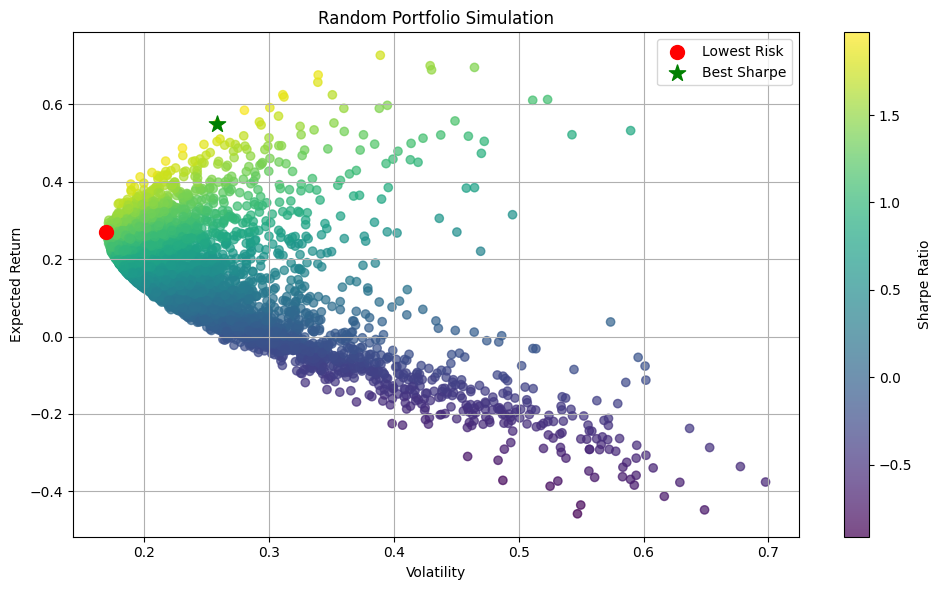

In [ ]:
best = results_df['Sharpe'].idxmax()
worst = results_df['Sharpe'].idxmin()
min_vol = results_df['Volatility'].idxmin()

print("\n Best Sharpe:\n", full_results.loc[best])
print("\n Worst Sharpe:\n", full_results.loc[worst])
print("\n Lowest Risk:\n", full_results.loc[min_vol])


# Below is visualization plots
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Volatility'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(*results_df.loc[min_vol, ['Volatility', 'Return']], c='red', s=100, label='Lowest Risk')
plt.scatter(*results_df.loc[best, ['Volatility', 'Return']], c='green', s=150, marker='*', label='Best Sharpe')
plt.title("Random Portfolio Simulation")
plt.xlabel("Volatility"), plt.ylabel("Expected Return")
plt.legend(), plt.grid(True), plt.tight_layout()
plt.show()


#Sharp Ratio

In [ ]:
rf_annual = 0.04  # 4% annual risk-free rate

# Expected annualized returns and volatility
expected_return = portfolio_returns.mean() * 252
volatility = portfolio_returns.std() * np.sqrt(252)

# Compute Sharpe Ratios
sharpe_ratios = (expected_return - rf_annual) / volatility

# Print Sharpe Ratios
for asset in assets:
    print(f"Sharpe Ratio ({asset}): {sharpe_ratios[asset]:.4f}")


Sharpe Ratio (SBRY.L): 1.0648
Sharpe Ratio (TSCO.L): 1.1734
Sharpe Ratio (MKS.L): 0.1570
Sharpe Ratio (KGF.L): 0.1694
Sharpe Ratio (NXT.L): 1.4525
Sharpe Ratio (OCDO.L): -0.5573


#MVP

In [ ]:
# Reformat data for PyPortfolioOpt
mu = expected_return[assets] # expected return
S = cov.loc[assets, assets] # covariance

In [ ]:
# PyPortfolioOpt Efficient Frontier (allows short selling)
ef = EfficientFrontier(expected_return, cov, weight_bounds=(-1, 1))
# Minimum Variance Portfolio
w_pypfopt_mvp = ef.min_volatility()
cleaned_mvp = ef.clean_weights()

ret_pypfopt_mvp, vol_pypfopt_mvp, sharpe_pypfopt_mvp = ef.portfolio_performance()



In [ ]:
print(cleaned_mvp)
print(ret_pypfopt_mvp)
print(vol_pypfopt_mvp)

OrderedDict({'SBRY.L': 0.198, 'TSCO.L': 0.35309, 'MKS.L': -0.04275, 'KGF.L': 0.13266, 'NXT.L': 0.31135, 'OCDO.L': 0.04764})
0.2811434637266517
0.1680329089507958


#MSR

In [ ]:
ef_msr = EfficientFrontier(mu, S, weight_bounds=(-1, 1))
# Maximum Sharpe Ratio
w_pypfopt_msr = ef_msr.max_sharpe()
cleaned_msr = ef_msr.clean_weights()

ret_pypfopt_msr, vol_pypfopt_msr, sharpe_pypfopt_msr = ef_msr.portfolio_performance()

In [ ]:
print(cleaned_msr)
print(ret_pypfopt_msr)
print(vol_pypfopt_msr)

OrderedDict({'SBRY.L': 0.38001, 'TSCO.L': 0.42755, 'MKS.L': -0.41348, 'KGF.L': -0.02101, 'NXT.L': 0.70711, 'OCDO.L': -0.08018})
0.5022870350328029
0.22459823264709403


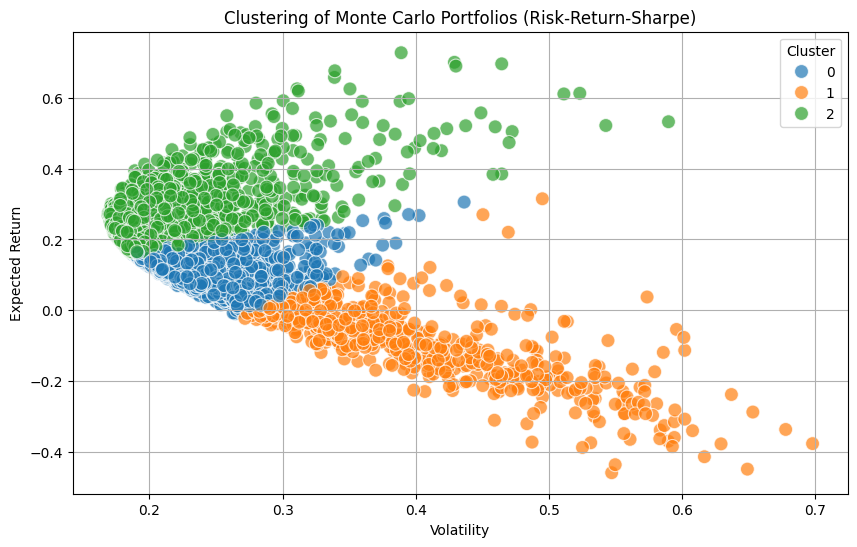

Average metrics per cluster:
            Return  Volatility    Sharpe
Cluster                                
0        0.115244    0.225819  0.350603
1       -0.070417    0.376290 -0.267071
2        0.230354    0.199834  0.945595


In [ ]:


# Step 1: Select features from Monte Carlo simulation
portfolio_features = results_df[['Return', 'Volatility', 'Sharpe']]

# Step 2: Scale the features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(portfolio_features)

# Step 3: Apply KMeans clustering
# You can choose n_clusters based on elbow method or domain knowledge; let's use 3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Step 4: Add cluster labels to your results DataFrame
results_df['Cluster'] = clusters

# Step 5: Visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=results_df, x='Volatility', y='Return', hue='Cluster', palette='tab10', s=100, alpha=0.7)
plt.title('Clustering of Monte Carlo Portfolios (Risk-Return-Sharpe)')
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Step 6: Examine cluster statistics
cluster_summary = results_df.groupby('Cluster')[['Return', 'Volatility', 'Sharpe']].mean()
print("Average metrics per cluster:\n", cluster_summary)
